# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Fawwaz Prayitno
- Email: fawwazprayitno@gmail.com
- Id Dicoding: fawwaz_Pu1r

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
# =========================
# Manipulation Libraries
# =========================
import pandas as pd
import numpy as np

# =========================
# Visualitation Libraries
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Praprocessing & Modelling Libraries
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =========================
# MODEL EVALUATION libraries
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# =========================
# MODEL SAVING libraries
# =========================
import joblib

# =========================
# STATISTICS / UTILITY
# =========================
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# =========================
# DISPLAY SETTINGS
# =========================
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

### Menyiapkan data yang akan diguankan

## Data Understanding

In [4]:
# =========================
# LOAD DATA
# =========================
df = pd.read_csv('data.csv', sep=';')

# Copy untuk keamanan (hindari overwrite data asli)
df_raw = df.copy()

print("-> Informasi dataset:")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

# =========================
# STRUKTUR DATA
# =========================
display(df.head())

print("\n-> Info Dataset:")
df.info()

print("\n-> Statistik Deskriptif (Numerik):")
display(df.describe().T)

print("\n-> Statistik Deskriptif (Kategorikal):")
display(df.describe(include='object').T)

# =========================
# MISSING VALUES (IMPROVED)
# =========================
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

# Filter hanya yang ada missing
missing_filtered = missing_df[missing_df['Missing Count'] > 0]

if missing_filtered.empty:
    print("Tidak ditemukan missing value pada dataset.")
else:
    print("Ditemukan missing value pada kolom berikut:\n")
    display(missing_filtered.sort_values(by='Missing %', ascending=False))

# =========================
# DUPLICATE DATA
# =========================
duplicates = df.duplicated().sum()

print(f"Jumlah data duplikat: {duplicates}")

# Optional: tampilkan sample duplicate
if duplicates > 0:
    display(df[df.duplicated()].head())


# =========================
# OUTLIER DETECTION (IQR)
# =========================
numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        'Column': col,
        'Outlier Count': len(outliers),
        'Outlier %': (len(outliers) / len(df)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Outlier %', ascending=False)

display(outlier_df)



-> Informasi dataset:
Jumlah baris: 4424
Jumlah kolom: 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



-> Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                        

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000



-> Statistik Deskriptif (Kategorikal):


,count,unique,top,freq
Status,4424,3,Graduate,2209


Tidak ditemukan missing value pada dataset.
Jumlah data duplikat: 0


,Column,Outlier Count,Outlier %
18,Scholarship_holder,1099,24.841772
31,Curricular_units_2nd_sem_grade,877,19.823689
25,Curricular_units_1st_sem_grade,726,16.410488
5,Previous_qualification,707,15.981013
21,Curricular_units_1st_sem_credited,577,13.042495
2,Application_order,541,12.228752
27,Curricular_units_2nd_sem_credited,530,11.980108
16,Tuition_fees_up_to_date,528,11.934901
0,Marital_status,505,11.415009
15,Debtor,503,11.369801


## Data Preparation / Preprocessing

Numerical: 39
Categorical: 0
Model berhasil dilatih


,Count,Percentage (%)
Status,,
Graduate,2209,49.932188
Dropout,1421,32.120253
Enrolled,794,17.947559


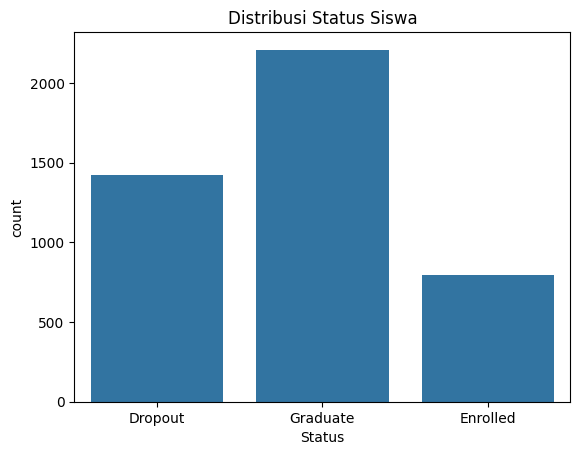

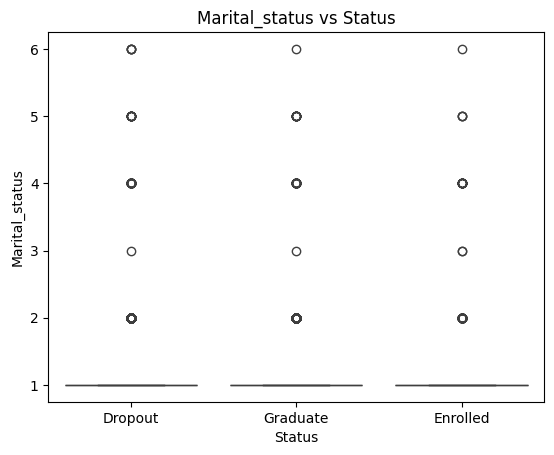

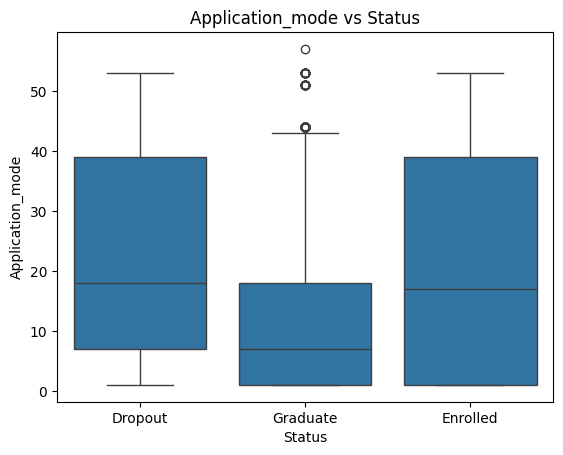

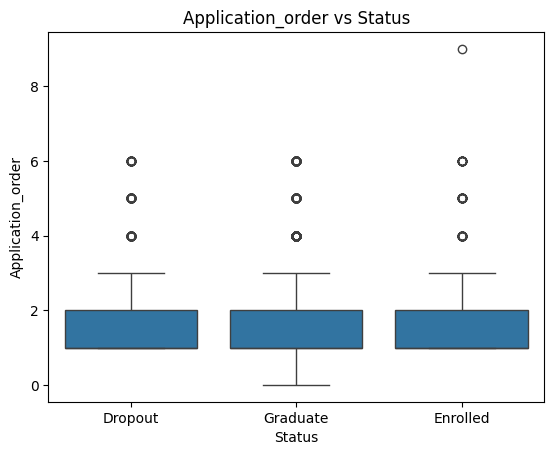

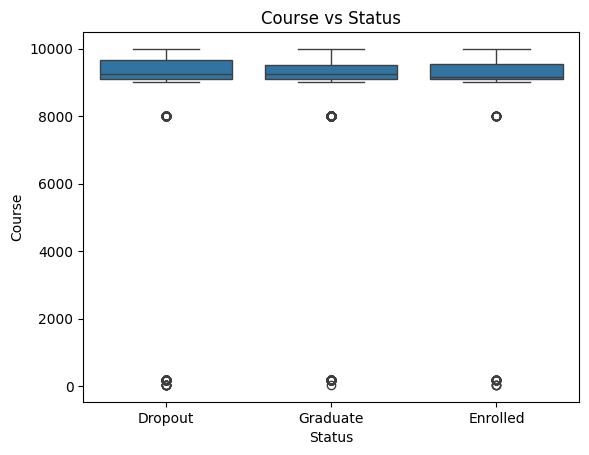

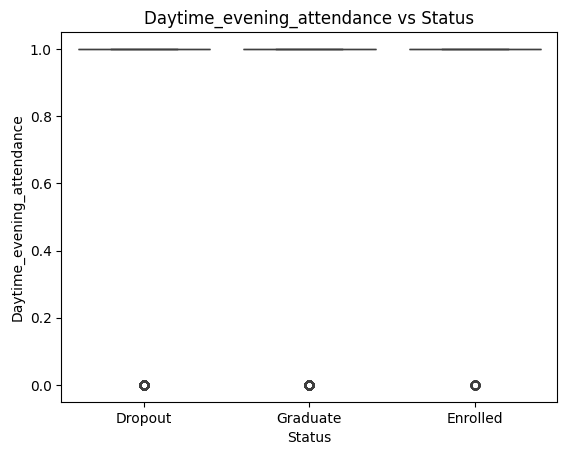

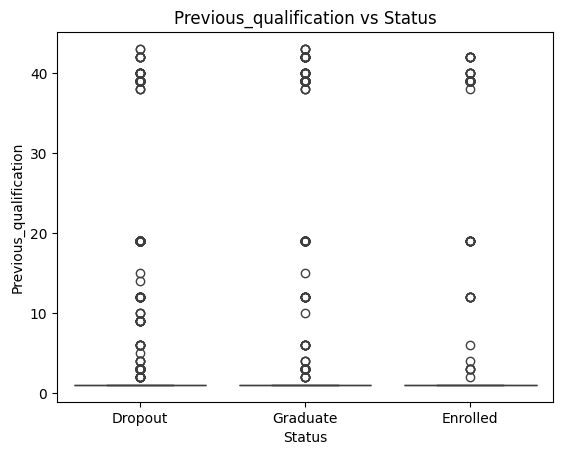

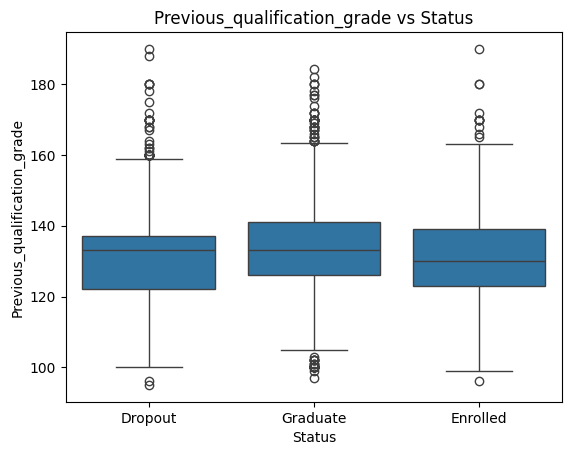

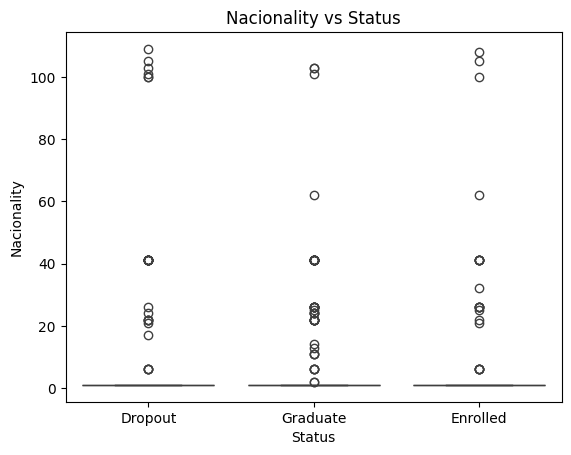

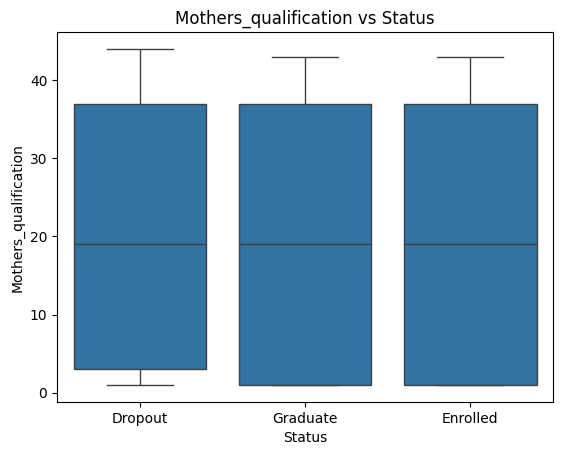

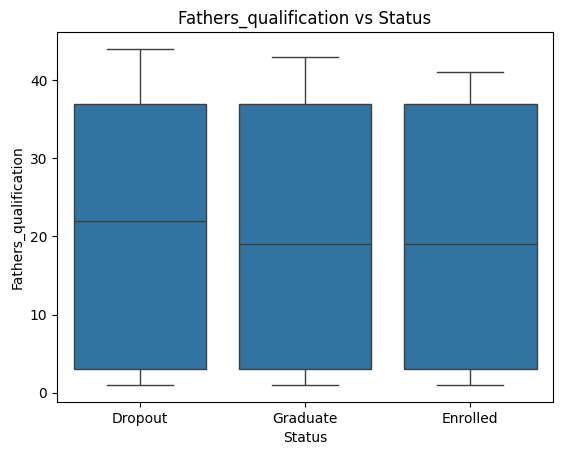

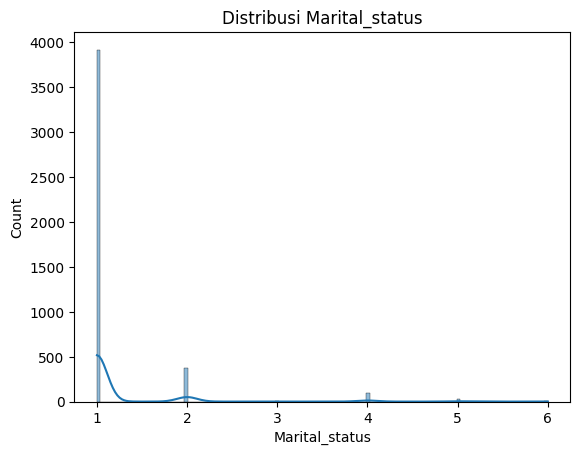

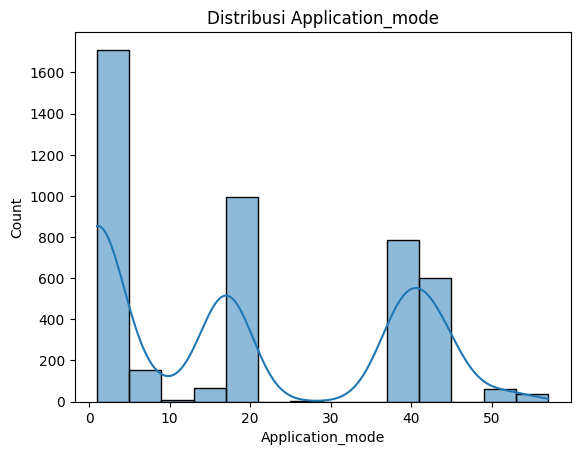

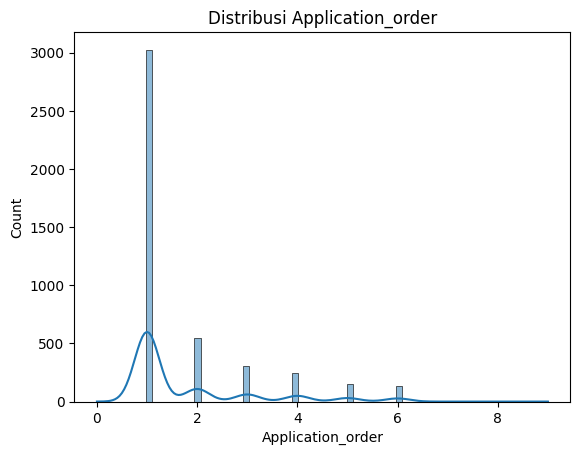

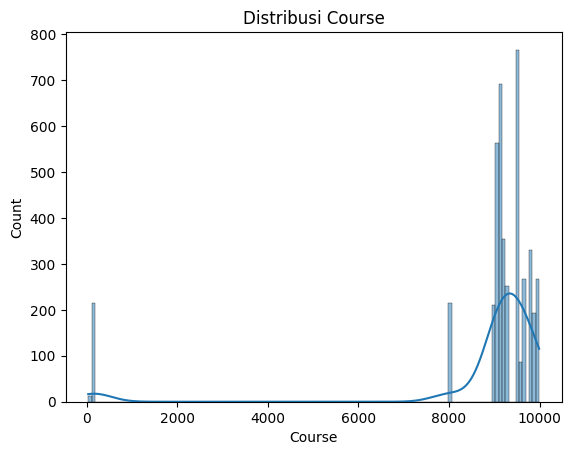

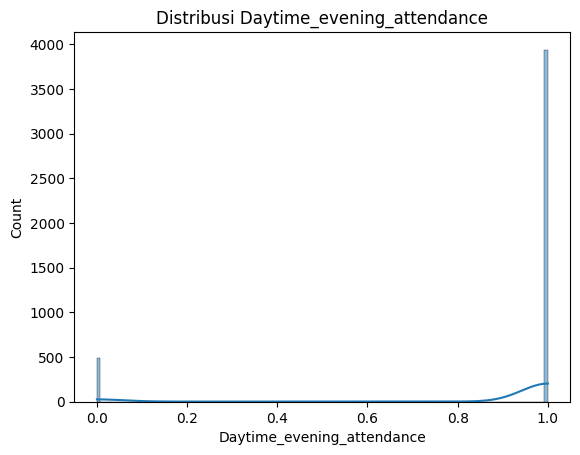

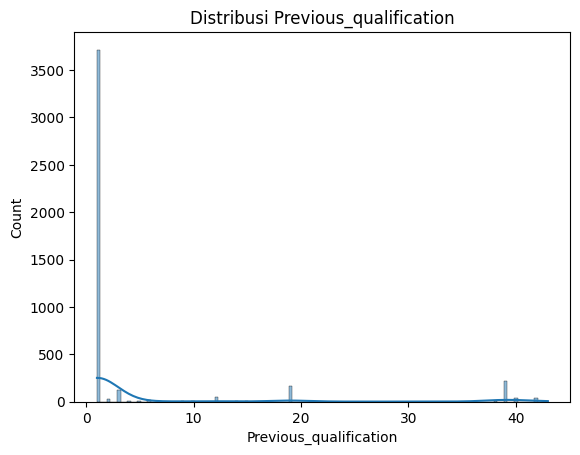

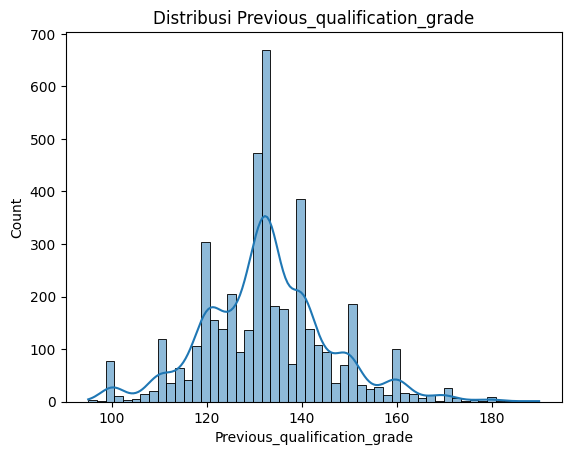

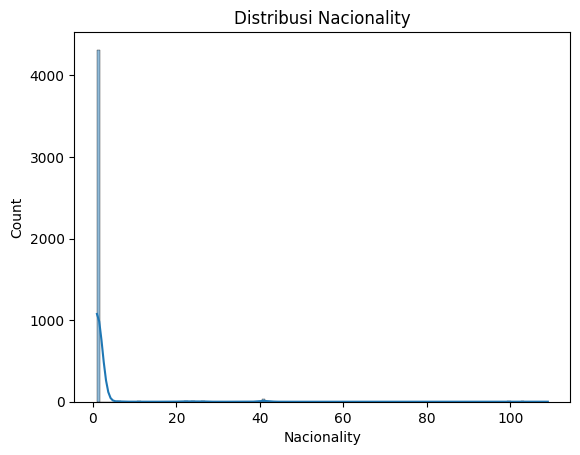

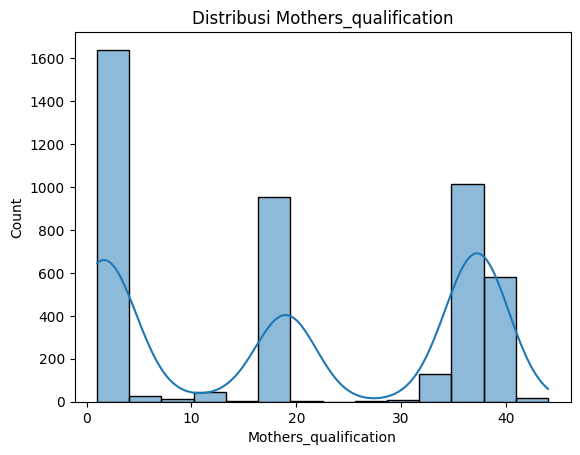

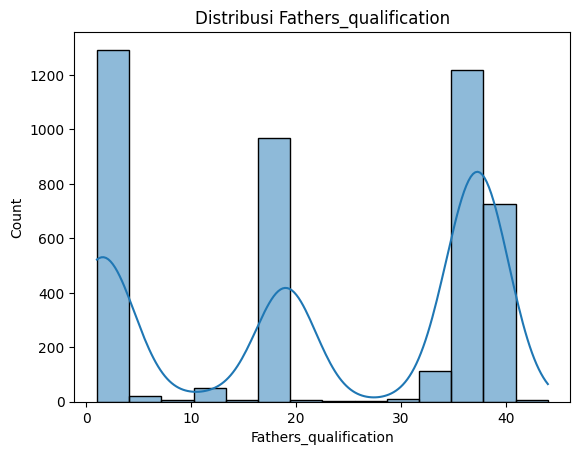

In [23]:
# =========================
# DATA CLEANING
# =========================
df = df.copy()

df.drop_duplicates(inplace=True)

target_col = 'Status'
X = df.drop(columns=[target_col])
y = df[target_col]

# =========================
# TRAIN TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# =========================
# FEATURE ENGINEERING (ANTI BIAS)
# =========================
def add_features(df):
    df = df.copy()
    
    # ✔ tren performa (valid secara logika)
    df['grade_trend'] = (
        df['Curricular_units_2nd_sem_grade'] -
        df['Curricular_units_1st_sem_grade']
    )
    
    # ✔ rata-rata performa
    df['avg_grade'] = (
        df['Curricular_units_1st_sem_grade'] +
        df['Curricular_units_2nd_sem_grade']
    ) / 2
    
    # ✔ rasio performa (lebih stabil)
    df['grade_ratio'] = df['Curricular_units_2nd_sem_grade'] / (
        df['Curricular_units_1st_sem_grade'] + 1
    )
    
    return df

# APPLY (WAJIB setelah split)
X_train = add_features(X_train)
X_test = add_features(X_test)

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

print("Model berhasil dilatih")

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

# =========================
# TARGET DISTRIBUTION
# =========================
target_dist = df[target_col].value_counts()
target_pct = df[target_col].value_counts(normalize=True) * 100

display(pd.DataFrame({
    'Count': target_dist,
    'Percentage (%)': target_pct
}))

sns.countplot(data=df, x=target_col)
plt.title("Distribusi Status Siswa")
plt.show()

# =========================
# NUMERICAL VS TARGET
# =========================
for col in num_cols[:10]:  # batasi agar tidak overload
    plt.figure()
    sns.boxplot(data=df, x=target_col, y=col)
    plt.title(f"{col} vs Status")
    plt.show()

# =========================
# DISTRIBUSI NUMERIK
# =========================
for col in num_cols[:10]:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribusi {col}")
    plt.show()



## Modeling

In [29]:
# =========================
# ENCODE TARGET
# =========================
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

dropout_label = 'Dropout'
dropout_idx = np.where(le.classes_ == dropout_label)[0][0]

# =========================
# MODEL CANDIDATES (SIMPLIFIED)
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        eval_metric='mlogloss',
        random_state=42,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05
    )
}

results = []
best_model = None
best_score = -np.inf

# =========================
# CROSS VALIDATION
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, base_model in models.items():

    print(f"\n🔹 Training {name}")

    cv_scores = []

    for train_idx, val_idx in skf.split(X_train, y_train_enc):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_enc[train_idx], y_train_enc[val_idx]

        # =========================
        # CALIBRATION (WAJIB UNTUK PROBABILITY)
        # =========================
        calibrated_model = CalibratedClassifierCV(
            base_model,
            method='sigmoid',   # 🔥 stabil (bukan isotonic)
            cv=3
        )

        pipeline_model = ImbPipeline([
            ('preprocessing', preprocessor),
            ('model', calibrated_model)
        ])

        # TRAIN
        pipeline_model.fit(X_tr, y_tr)

        # VALIDATION
        y_pred = pipeline_model.predict(X_val)
        y_proba = pipeline_model.predict_proba(X_val)

        # =========================
        # METRICS
        # =========================
        recall_macro = recall_score(y_val, y_pred, average='macro')
        f1_macro = f1_score(y_val, y_pred, average='macro')
        roc = roc_auc_score(y_val, y_proba, multi_class='ovr')

        recall_dropout = recall_score(
            y_val == dropout_idx,
            y_pred == dropout_idx
        )

        # =========================
        # ANTI-BIAS CHECK
        # =========================
        pred_dist = pd.Series(y_pred).value_counts(normalize=True)
        max_class_ratio = pred_dist.max()

        penalty = 0.05 if max_class_ratio > 0.6 else 0

        score = (
            0.4 * recall_dropout +
            0.3 * f1_macro +
            0.3 * roc
        ) - penalty

        cv_scores.append(score)

    final_score = np.mean(cv_scores)

    print(f"{name} CV Score: {final_score:.4f}")

    # =========================
    # FINAL TRAIN (FULL DATA)
    # =========================
    final_model = ImbPipeline([
        ('preprocessing', preprocessor),
        ('model', CalibratedClassifierCV(
            base_model,
            method='sigmoid',
            cv=3
        ))
    ])

    final_model.fit(X_train, y_train_enc)

    # =========================
    # TEST EVALUATION
    # =========================
    y_pred_test = final_model.predict(X_test)
    y_proba_test = final_model.predict_proba(X_test)

    recall_dropout_test = recall_score(
        y_test_enc == dropout_idx,
        y_pred_test == dropout_idx
    )

    results.append({
        "Model": name,
        "pipeline": final_model,
        "CV Score": final_score,
        "Recall Dropout": recall_dropout_test
    })

    # SELECT BEST MODEL
    if final_score > best_score:
        best_score = final_score
        best_model = final_model
        best_model_name = name

# =========================
# HASIL AKHIR
# =========================
results_df = pd.DataFrame(results).sort_values(by="CV Score", ascending=False)
display(results_df)

print("\n🏆 Best Model:", best_model_name)

# =========================
# DISTRIBUSI PREDIKSI
# =========================
pred_distribution = pd.Series(best_model.predict(X_test)).value_counts(normalize=True)

print("\nDistribusi Prediksi:")
print(pred_distribution)

# =========================
# VALIDASI LOGIKA (SANITY CHECK)
# =========================
print("\nSanity Check:")
sample = X_test.sample(5, random_state=42)
print(best_model.predict_proba(sample))

# =========================
# SAVE MODEL
# =========================
joblib.dump(best_model, 'model.pkl')
joblib.dump(X_train.columns.tolist(), 'columns.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Model berhasil disimpan")

Label mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

🔹 Training Logistic Regression
Logistic Regression CV Score: 0.6995

🔹 Training Random Forest
Random Forest CV Score: 0.7716

🔹 Training XGBoost
XGBoost CV Score: 0.7866


,Model,pipeline,CV Score,Recall Dropout
2,XGBoost,"(ColumnTransformer(transformers=[('num',\n ...",0.786601,0.750000
1,Random Forest,"(ColumnTransformer(transformers=[('num',\n ...",0.771625,0.739437
0,Logistic Regression,"(ColumnTransformer(transformers=[('num',\n ...",0.699518,0.816901



🏆 Best Model: XGBoost

Distribusi Prediksi:
2    0.568362
0    0.301695
1    0.129944
Name: proportion, dtype: float64

Sanity Check:
[[0.08321934 0.09047378 0.82630688]
 [0.79520628 0.0935547  0.11123902]
 [0.86916097 0.07754477 0.05329425]
 [0.07169342 0.07679528 0.8515113 ]
 [0.28346479 0.26968185 0.44685336]]
Model berhasil disimpan


## Evaluation

In [30]:
# =========================
# EVALUATION - METRICS (FIXED)
# =========================

evaluation_results = []

dropout_label = 'Dropout'
dropout_idx = np.where(le.classes_ == dropout_label)[0][0]

for res in results:
    name = res["Model"]
    pipeline = res["pipeline"]

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    acc = accuracy_score(y_test_enc, y_pred)
    prec = precision_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    roc = roc_auc_score(y_test_enc, y_proba, multi_class='ovr')

    recall_dropout = recall_score(
        y_test_enc == dropout_idx,
        y_pred == dropout_idx
    )

    evaluation_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc,
        "Recall Dropout": recall_dropout
    })

eval_df = pd.DataFrame(evaluation_results)\
    .sort_values(by="Recall Dropout", ascending=False)

display(eval_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Recall Dropout
0,Logistic Regression,0.755932,0.732285,0.755932,0.694194,0.866285,0.816901
2,XGBoost,0.766102,0.754715,0.766102,0.756146,0.889341,0.750000
1,Random Forest,0.766102,0.753939,0.766102,0.754913,0.887626,0.739437
